# ER Diagram

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import pyqtgraph
print(pyqtgraph.__file__)
import neuroanalysis
print(neuroanalysis.__file__)
import neuroanalysis.util
import aisynphys
import aisynphys.database
print(aisynphys.__file__)

from IPython.display import display, Markdown

c:\Users\snrambo\AppData\Local\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\snrambo\neuroanalysis\neuroanalysis\__init__.py
C:\Users\snrambo\aisynphys\aisynphys\__init__.py


# Set up DB connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [2]:
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access
from pathlib import Path

# Define cache directory
CACHE_PATH = Path("data/aisynphys/cache").resolve()

# Create a cache directory if it does not exist
CACHE_PATH.mkdir(parents=True, exist_ok=True)

# Tell AISynPhys to use this cache
aisynphys.config.cache_path = CACHE_PATH
# SynphysDatabase.set_cache_path(CACHE_PATH)


# Make cache
DATA_ROOT = Path("data/aisynphys/cache")

# Inspect available database versions
SynphysDatabase.list_versions()  # List all available versions

# Load small database -- Uncomment to load
# DB_VERSION = 'synphys_r2.1_medium.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

[{'db_file': 'synphys_r1.0_2019-08-29_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_2019-08-29_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_2019-08-29_full.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_full.sqlite',
  'schema_

In [3]:
# Get file path and ensure it exist
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # database

assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [4]:
# Create SQLite connection to SQLite database

con = sqlite3.connect(DB_PATH)  # Create a connection object that "connects to the database"
cur = con.cursor()  # database cursor

# Table overview

In [5]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


# Formatting for figures

In [21]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

# Explore tables

In [6]:
query = """
            SELECT DISTINCT qual_morpho_type FROM morphology
        """

df = pd.read_sql_query(query, con)

df

,qual_morpho_type
0,None
1,L2/3 IT cell
2,L5 IT
3,L6a non-tuffed/simple tuft
4,Martinotti Cell
5,Martinotti cell
6,"Tufted L4,5"
7,bipolar
8,bipolar cell
9,bipolar cell?


In [7]:
query = """
            SELECT DISTINCT target_region FROM experiment
        """

df = pd.read_sql_query(query, con)

df

,target_region
0,VisP
1,ALM
2,TCx
3,FCx
4,None
5,
6,PCx
7,TEa
8,ACC
9,OCx


In [8]:
query = """
            SELECT DISTINCT species FROM slice
        """

df = pd.read_sql_query(query, con)

df

,species
0,mouse
1,human



VisP: Primary Visual Cortex
ALM: Anterior Lateral Motor Cortex
TCx: Temporal Cortex
FCx: Frontal Cortex
None
  (empty):
PCx: Piriform Cortex
TEa: Temporal Association Area
ACC: Anterior Cingulate Cortex
OCx: Occipital Cortex

TODO
* Clean data: Only include relevant 
    * Mouse
    * Target region_ VisP
    * Pairs in this


# Querying 

In [9]:
df = pd.read_sql_query(
    # "SELECT COUNT(DISTINCT id) FROM pair;"
    "SELECT * FROM pair LIMIT 4"
    , con)
df

,id,experiment_id,pre_cell_id,post_cell_id,has_synapse,has_polysynapse,has_electrical,crosstalk_artifact,n_ex_test_spikes,n_in_test_spikes,distance,lateral_distance,vertical_distance,reciprocal_id,meta
0,1,1,1,2,None,None,None,None,0,0,None,None,None,17,null
1,2,2,3,7,None,None,None,None,0,0,None,None,None,13,null
2,3,2,3,9,None,None,None,None,0,0,None,None,None,24,null
3,4,1,1,4,None,None,None,None,0,0,None,None,None,32,null


In [14]:
df = pd.read_sql_query("SELECT * FROM cell LIMIT 4", con)
df

,id,experiment_id,ext_id,electrode_id,cre_type,target_layer,position,depth,cell_class,cell_class_nonsynaptic,meta
0,1,1,1,1,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
1,2,1,2,2,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
2,3,2,2,9,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."
3,4,1,3,3,unknown,,null,None,None,None,"{""lims_specimen_id"": null, ""transgenic_cell_cl..."


## Valid experiments

We want all cell pairs that:

* Belong to an experiment
* Belong to a mouse slice
* Experiment targets VisP
* Both cells exist
* Both cell classes are known
* Presynaptic cell is not mixed

In [27]:
# df_slice = pd.read_sql_query("SELECT mouse_id FROM slice  WHERE species = 'mouse'", con)  # IDs of mouse
# df_experiment_ids = pd.read_sql_query("SELECT id AS exp_id FROM experiment WHERE target_region = 'VisP'", con)  # IDs of experiments in Primary Visual Cortex
# df_cell = pd.read_sql_query("SELECT * FROM cell", con)
# df_pair = pd.read_sql_query("SELECT * FROM pair", con)

df = pd.read_sql_query("SELECT DISTINCT cell_class from cell", con)
df

,cell_class
0,None
1,ex
2,in
3,mixed


In [10]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                --e.id AS experiment_id, 
                p.experiment_id,
                p.pre_cell_id, 
                p.post_cell_id, 
                p.has_synapse, 
                pre.cell_class AS pre_cell_class,
                post.cell_class AS post_cell_class

            FROM pair p

            -- Join on both pre and post synaptic cell
            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id

            -- Join with experiment and slice
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id

            -- Filter out what is relevant for us
            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'; 
        """

df_valid_experiments = pd.read_sql_query(query, con)

df_valid_experiments


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


In [11]:
print(len(df_valid_experiments["experiment_id"].unique()))  # unique experiments

2441


## Aggregating to see counts of synapses

Querying using aggregation

In [12]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id;
        """

df_synapses = pd.read_sql_query(query, con)

df_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,25,12,0,12
1,35,2,0,2
2,36,9,0,9
3,38,6,0,6
4,39,20,0,20
...,...,...,...,...
2436,5265,6,4,2
2437,5266,1,1,0
2438,5267,2,0,2
2439,5268,2,1,1


## Info

In [13]:
# How many in total
total_synapses = df_synapses["num_synapses"].sum()
total_not_synapses = df_synapses["num_no_synapses"].sum()
print(f"Total synapses: {total_synapses}")
print(f"Total not synapses: {total_not_synapses}")

# Get IDs of valid experiments
valid_experiments = df_synapses["experiment_id"].tolist()
print(f"Number of unique experiments: {len(valid_experiments)}")



# Total involved neurons
pre_ids = df_valid_experiments["pre_cell_id"].unique().tolist()
post_ids = df_valid_experiments["post_cell_id"].unique().tolist()
print(f"Number of presynaptic cells involved: {len(pre_ids)}")
print(f"Number of postsynaptic cells involved: {len(post_ids)}")

# Number of total involved neurons:
all_cells_involved = list(set(pre_ids) | set(post_ids))  # returns the set union of the two lists, and then convert back to list (to not have duplicates)

n = len(all_cells_involved)
print(f"Number of cells involved in total: {n}")

possible_synapses = n * (n - 1)  # in a complete directed graph with no self loop we get n(n-1)

df_valid_experiments
df_synapses

Total synapses: 2440
Total not synapses: 34681
Number of unique experiments: 2441
Number of presynaptic cells involved: 9670
Number of postsynaptic cells involved: 9870
Number of cells involved in total: 9922


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,25,12,0,12
1,35,2,0,2
2,36,9,0,9
3,38,6,0,6
4,39,20,0,20
...,...,...,...,...
2436,5265,6,4,2
2437,5266,1,1,0
2438,5267,2,0,2
2439,5268,2,1,1


In [41]:
df_valid_experiments

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


Using the already made DF

In [32]:
# How many in total
total_synapses = df_synapses["num_synapses"].sum()
total_not_synapses = df_synapses["num_no_synapses"].sum()
print(f"Total synapses: {total_synapses}")
print(f"Total not synapses: {total_not_synapses}")

# Get IDs of valid experiments
valid_experiments = df_synapses["experiment_id"].tolist()
print(f"Number of unique experiments: {len(valid_experiments)}")



# Total involved neurons
pre_ids = df_valid_experiments["pre_cell_id"].unique().tolist()
post_ids = df_valid_experiments["post_cell_id"].unique().tolist()
print(f"Number of presynaptic cells involved: {len(pre_ids)}")
print(f"Number of postsynaptic cells involved: {len(post_ids)}")

# Number of total involved neurons:
all_cells_involved = list(set(pre_ids) | set(post_ids))  # returns the set union of the two lists, and then convert back to list (to not have duplicates)

n = len(all_cells_involved)
print(f"Number of cells involved in total: {n}")

possible_synapses = n * (n - 1)  # in a complete directed graph with no self loop we get n(n-1)

df_was_synapse = (df_synapses[df_synapses["num_synapses"]>0])
was_synapse = df_was_synapse["experiment_id"].unique().tolist()
df_was_not_synapse = (df_synapses[df_synapses["num_synapses"]==0])
was_not_synapse = df_was_not_synapse["experiment_id"].unique().tolist()
print(f"Unique experiments: {valid_experiments}")
print(f"Experiments where there was a synapse: {len(was_synapse)}")
print(f"Experiments where there was not any synapse: {len(was_not_synapse)}")

df_valid_experiments
# df_synapses

Total synapses: 2440
Total not synapses: 34681
Number of unique experiments: 2441
Number of presynaptic cells involved: 9670
Number of postsynaptic cells involved: 9870
Number of cells involved in total: 9922
Unique experiments: [25, 35, 36, 38, 39, 40, 44, 46, 49, 52, 53, 54, 57, 59, 61, 63, 64, 65, 66, 67, 73, 78, 79, 80, 81, 82, 85, 86, 87, 89, 96, 97, 98, 99, 103, 104, 106, 108, 110, 113, 117, 119, 122, 134, 137, 143, 144, 145, 152, 153, 155, 160, 162, 163, 164, 165, 168, 169, 170, 171, 174, 177, 179, 182, 184, 185, 186, 188, 194, 195, 196, 197, 198, 199, 200, 201, 202, 205, 207, 210, 213, 215, 219, 221, 223, 225, 226, 230, 233, 235, 236, 241, 243, 244, 245, 247, 248, 249, 250, 253, 254, 255, 256, 257, 259, 260, 261, 263, 264, 267, 269, 270, 271, 273, 274, 277, 278, 279, 280, 283, 284, 287, 288, 289, 290, 291, 292, 294, 295, 296, 297, 298, 299, 300, 303, 304, 305, 306, 307, 308, 310, 312, 314, 315, 316, 317, 320, 321, 322, 323, 325, 326, 330, 331, 333, 334, 335, 338, 339, 340, 341,

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class
0,25,158,159,0,in,in
1,25,158,161,0,in,in
2,25,158,163,0,in,in
3,25,159,158,0,in,in
4,25,159,161,0,in,in
...,...,...,...,...,...,...
37116,5269,24845,24848,1,ex,in
37117,5269,24847,24845,0,ex,ex
37118,5269,24847,24848,0,ex,in
37119,5269,24848,24845,0,in,ex


In [23]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 12,             # X tick label size (8-12)
    "ytick.labelsize": 12,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

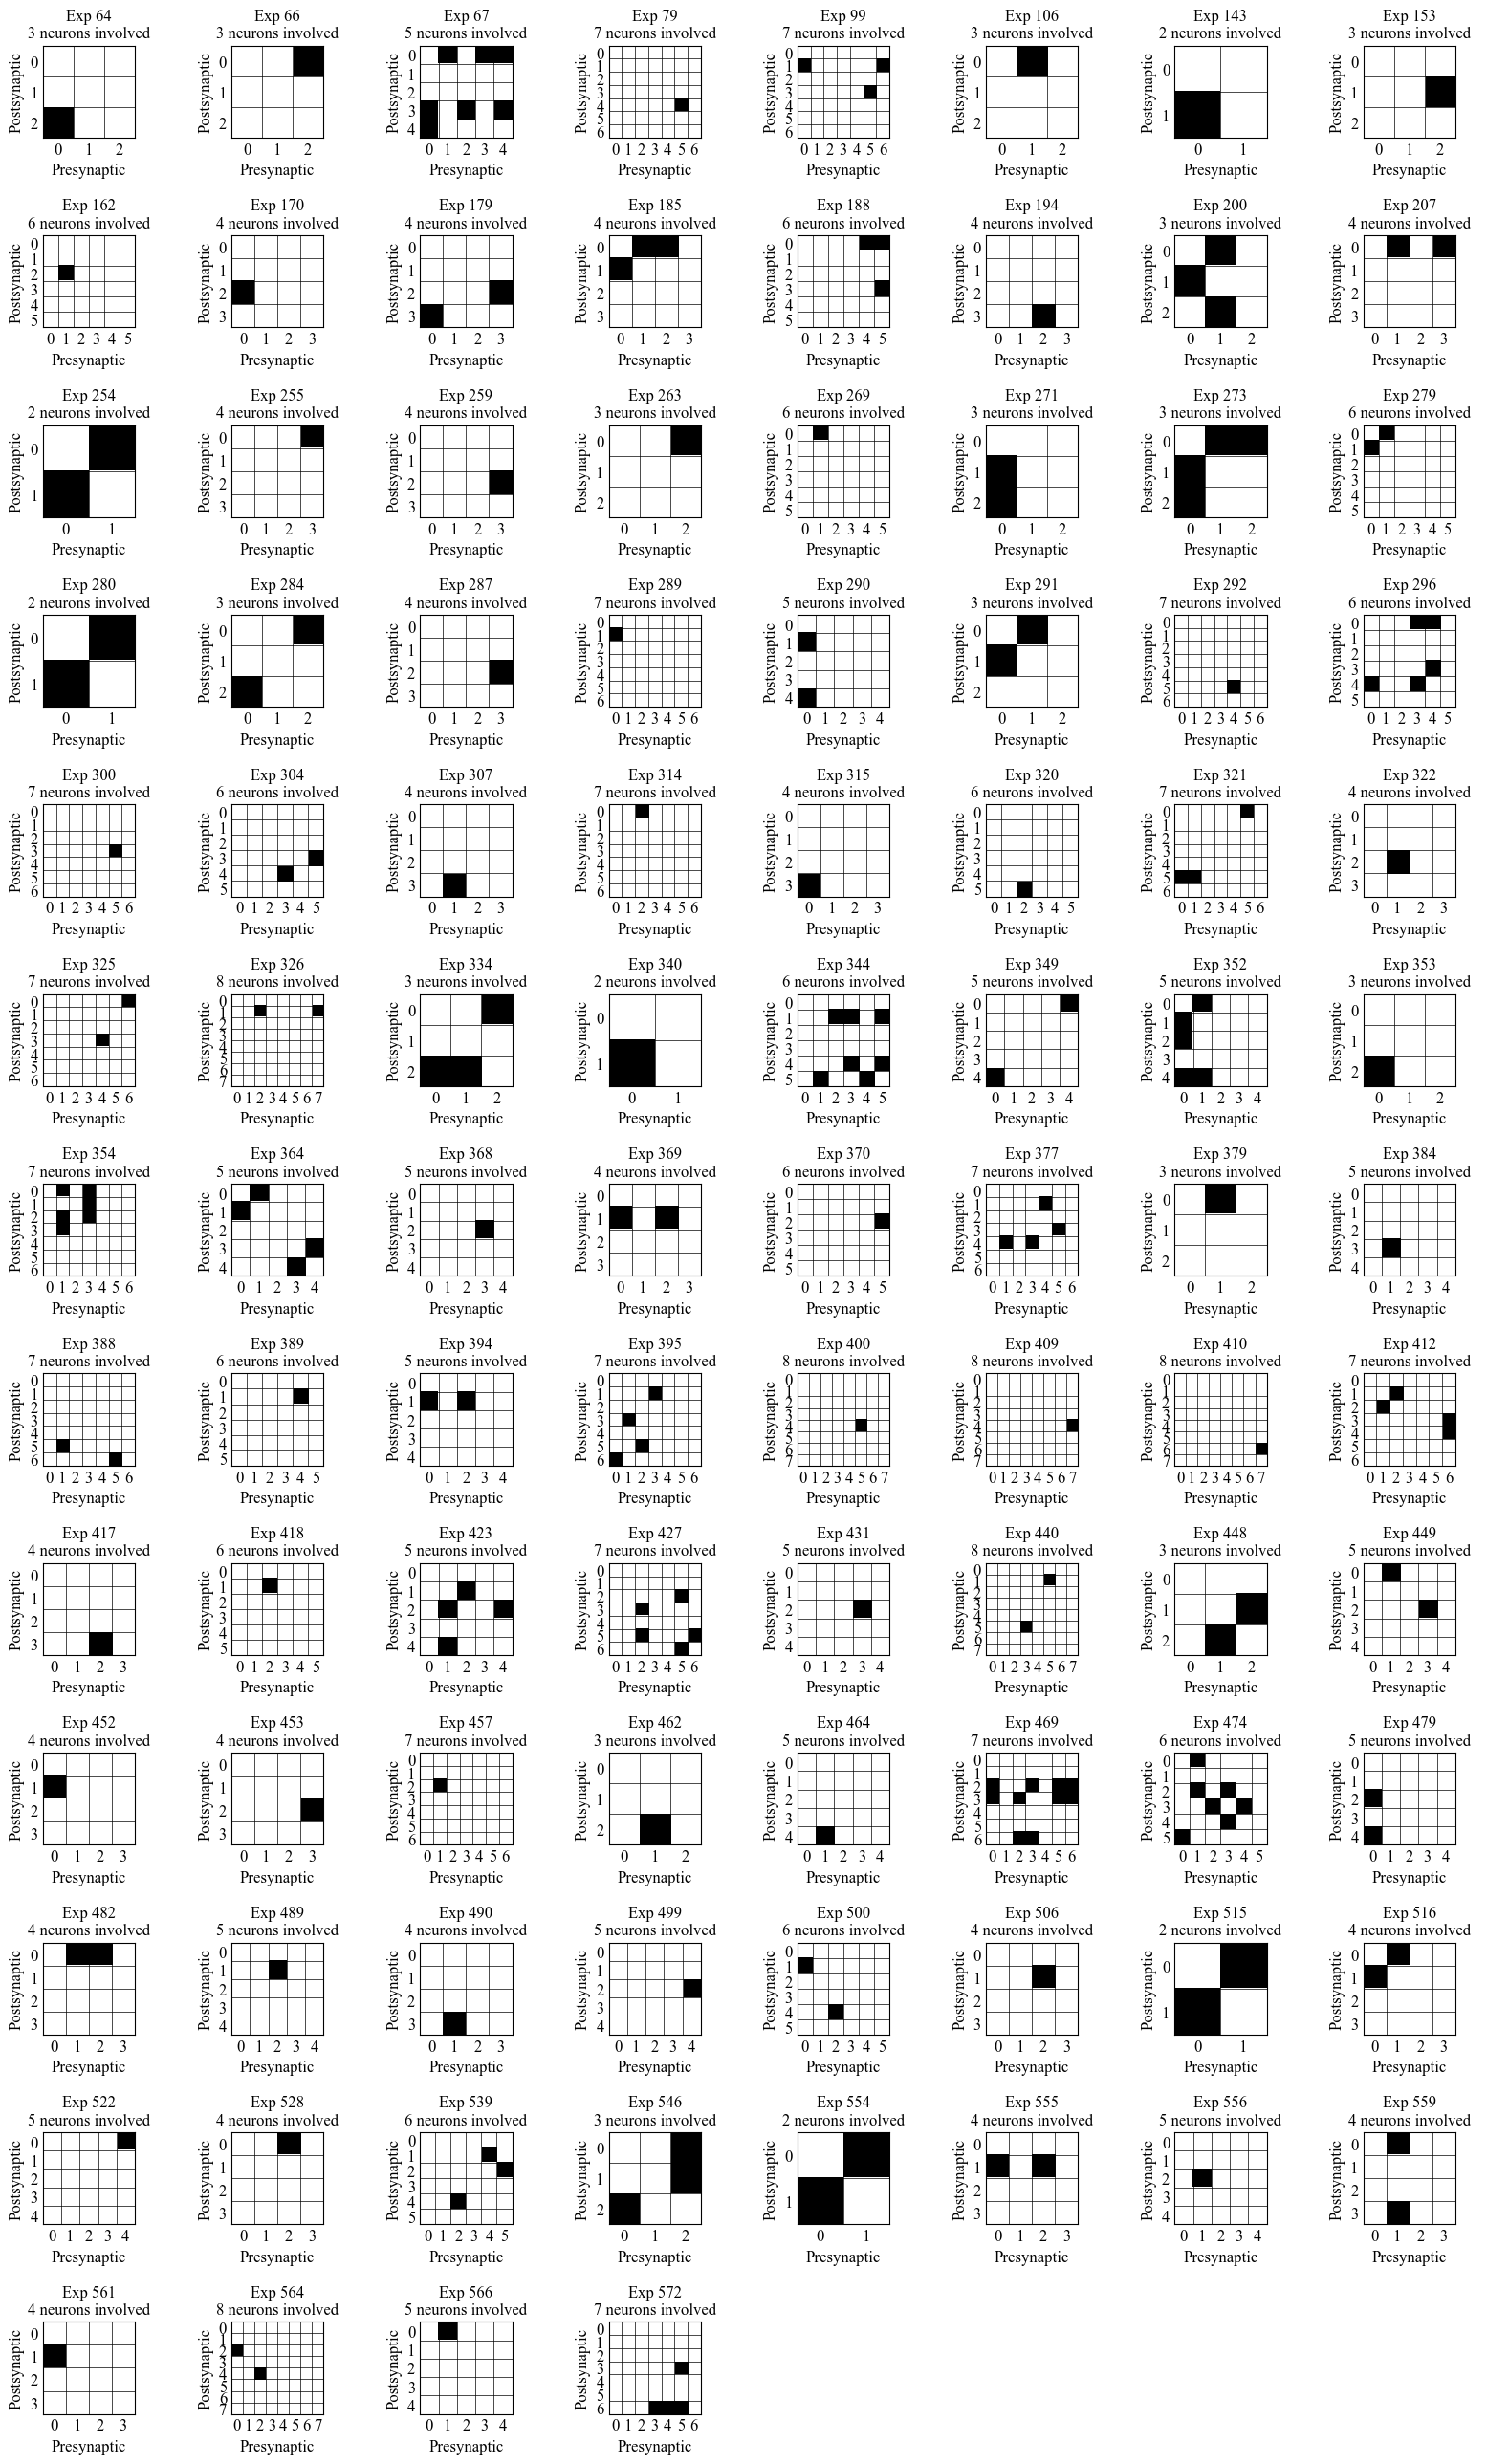

In [33]:
completed_experiments = []

# for exp in valid_experiments:
for exp in was_synapse:
    df = df_valid_experiments[(df_valid_experiments["experiment_id"]==exp)]
    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    totals = list(set(pres) | set(posts))
    n = len(totals)
    possible_synapses = n * (n - 1)

    df_distinct_cells = df[df["pre_cell_id"] != df["post_cell_id"]]  # distinct cells in pre and post
    unique_synapses = df_distinct_cells[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # drop duplicates

    if len(unique_synapses == possible_synapses):
        completed_experiments.append((exp, df, totals))



# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(completed_experiments))
n_cols = 8
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

# Make adjacency matrices
for i, (exp, df, totals) in enumerate(completed_experiments[:n_max]):
    n = len(totals)
    idx_map = {neuron: idx for idx, neuron in enumerate(totals)}  # mapping neuron to index
    adj = np.zeros((n, n))

    for _, row in df.iterrows():  # iterates through the dataframe
        # if row["experiment_id"] in was_not_synapse:
        #     continue
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0

    ax = axs[i]
    im = ax.imshow(adj, cmap="Greys", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    ax.set_xticklabels(np.arange(neurons))
    ax.set_yticklabels(np.arange(neurons))

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)
    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)

    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=12)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?


# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()



In [20]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses != 0;
        """

df_onlysynapse = pd.read_sql_query(query, con)

df_onlysynapse

,experiment_id,total_pairs,num_synapses,num_no_synapses
0,64,6,1,5
1,66,6,1,5
2,67,20,7,13
3,79,42,1,41
4,99,42,3,39
...,...,...,...,...
1081,5264,12,1,11
1082,5265,6,4,2
1083,5266,1,1,0
1084,5268,2,1,1


In [19]:
print(1086 + 1355)

2441


To look for where it is above some number of synapses we can use having:

In [57]:
# SQL query to retrieve the desired info

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 10;
        """

df_synapses = pd.read_sql_query(query, con)

df_synapses


,experiment_id,total_pairs,num_synapses,num_no_synapses
0,1504,42,11,31
1,1864,30,11,19
2,2771,30,11,19
3,2808,20,12,8
4,3172,56,19,37
5,3228,30,12,18
6,3262,42,11,31


#### Debugging row differences with the other version

**Subtract differences too see why I get less rows**

In [ ]:
df_slice = pd.read_sql_query("SELECT * from "+ str(table_list[2])[2:-3], con)
df_experiment = pd.read_sql_query("SELECT * from "+ str(table_list[3])[2:-3], con)
df_cell = pd.read_sql_query("SELECT * from "+ str(table_list[7])[2:-3], con)
df_pair = pd.read_sql_query("SELECT * from "+ str(table_list[9])[2:-3], con)


# Obtener los experimentos en df2 que son de ratón
######## Get the experiments in df_2 = df_slice that are mouse
mouse_ids = df_slice[df_slice['species'] == 'mouse']['id']

# Obtener los experimentos en df3 que tienen target_region == VISp
######## Get the experiments in df_3 = df_experiment that have target_region == VISp
visp_ids = df_experiment[df_experiment['target_region'] == 'VisP']['id']
print(visp_ids)

# Intersección de ambos conjuntos de experimentos
######## Intersection of both sets of experiments
valid_exp_ids = set(mouse_ids).intersection(set(visp_ids))

# Filtrar df9 con esos experimentos válidos
######## Filter df9 = df_pair with those valid experiments
df_pair_2 = df_pair[df_pair['experiment_id'].isin(mouse_ids)]


df_merged = pd.merge(df_pair[['id', 'experiment_id', 'has_synapse', 'pre_cell_id', 'post_cell_id']],
                     df_cell[['id', 'cell_class']],
                     left_on='pre_cell_id', right_on='id')
df_merged.rename(columns={'cell_class': 'pre_cell_class'}, inplace=True)

# Seleccionamos y ordenamos las columnas deseadas
df_result = df_merged[['experiment_id','pre_cell_id', 'post_cell_id', 'has_synapse', 'pre_cell_class']]
df_result = df_result[df_result['pre_cell_class']!= 'mixed']

# Merge adicional entre post_cell_id y id en df7
df_result = pd.merge(df_result,
                     df_cell[['id', 'cell_class']],
                     left_on='post_cell_id', right_on='id',
                     suffixes=('_pre', '_post'))

# Filtramos los resultados para que los 'pre_cell_class' no sean 'mixed'
df_result = df_result[df_result['pre_cell_class'] != 'mixed']

# Si quieres cambiar el nombre de la columna 'cell_class_post' por ejemplo, puedes hacerlo de la siguiente manera:
df_result.rename(columns={'cell_class': 'post_cell_class'}, inplace=True)


df_result = df_result[['experiment_id','pre_cell_id', 'post_cell_id', 'has_synapse', 'pre_cell_class', 'post_cell_class']]
df_clean = df_result.dropna(subset=['pre_cell_class', 'post_cell_class', 'has_synapse'])

# display(df_clean)

df_check = df_clean.merge(
    df_experiment[['id', 'target_region']],
    left_on='experiment_id',
    right_on='id',
    how='left'
)

print("checking")
df_check['target_region'].value_counts()

#### TEST: Other regions were included

df_check = df_clean.merge(
    df_experiment[['id', 'target_region']],
    left_on='experiment_id',
    right_on='id',
    how='left'
)

print("checking")
df_check['target_region'].value_counts()

0          1
1          2
2          3
3          4
4          5
        ... 
5053    5265
5054    5266
5055    5267
5056    5268
5057    5269
Name: id, Length: 4369, dtype: int64
checking


target_region
VisP    37127
TCx      2573
          213
FCx       166
ALM        90
PCx        85
TEa        30
Name: count, dtype: int64